# NFL Defensive Playcaller Assistant

This notebook implements the CS 153 project pipeline: a system that recommends defensive sub-package + play-style for a given game situation by combining a quantitative Random Forest model with a qualitative RAG + LLM synthesis layer.

**Scope:** 3rd and 4th down situations, 2025 NFL regular season.

**Action space:**
- Sub-package: `Base`, `Nickel`, `Dime`
- Play-style: `Man`, `Zone`, `Pressure`

## 0. Environment Setup

Check for and install missing dependencies.

In [3]:
import importlib
import subprocess
import sys

REQUIRED = {
    "pandas": "pandas",
    "numpy": "numpy",
    "matplotlib": "matplotlib",
    "sklearn": "scikit-learn",
    "nfl_data_py": "nfl_data_py",
    "pyarrow": "pyarrow",
    "chromadb": "chromadb",
}

missing = []
for module, package in REQUIRED.items():
    if importlib.util.find_spec(module) is None:
        missing.append(package)

if missing:
    print(f"Installing missing packages: {missing}")
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])
    print("Done.")
else:
    print("All dependencies satisfied.")

All dependencies satisfied.


## 1. Data Ingestion (Weeks 1–2)

Pull play-by-play data for the 2025 NFL regular season using `nfl_data_py`, then filter down to the canonical schema needed for the defensive recommendation model.

**Target columns:**
| Column | Role |
|---|---|
| `game_id` | Unique game identifier |
| `play_id` | Unique play identifier |
| `week` | Season week |
| `posteam` / `defteam` | Possession / defending team |
| `down` | Down number |
| `ydstogo` | Yards needed for conversion |
| `yardline_100` | Distance from end zone |
| `score_differential` | Score diff at snap (pos team POV) |
| `game_seconds_remaining` | Clock context |
| `offense_personnel` | Personnel string (e.g. "1 RB, 1 TE, 3 WR") |
| `defenders_in_box` | Defensive box count |
| `epa` | Expected points added (target proxy) |
| `success` | Binary: EPA > 0 from offensive POV |
| `third_down_converted` | 3rd down conversion flag |
| `fourth_down_converted` | 4th down conversion flag |
| `play_type` | pass / run / etc. |

In [2]:
import pandas as pd
import numpy as np
import nfl_data_py as nfl

print("Pulling play-by-play data for the 2024–2025 seasons...")
pbp_raw = nfl.import_pbp_data(years=[2024, 2025], downcast=True)
print(f"Raw shape: {pbp_raw.shape}")
pbp_raw.head(2)

Pulling play-by-play data for the 2024–2025 seasons...
2024 done.
2025 done.
Downcasting floats.
Raw shape: (98263, 397)


,play_id,game_id,old_game_id_x,home_team,away_team,season_type,week,posteam,posteam_type,defteam,...,was_pressure,route,defense_man_zone_type,defense_coverage_type,offense_names,defense_names,offense_positions,defense_positions,offense_numbers,defense_numbers
0,1.0,2024_01_ARI_BUF,2024090801,BUF,ARI,REG,1,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,40.0,2024_01_ARI_BUF,2024090801,BUF,ARI,REG,1,ARI,away,BUF,...,False,,,NaN,Max Melton;Joey Blount;Dadrion Taylor-Demerson...,Kaiir Elam;Ja'Marcus Ingram;Kameron Cline;Regg...,CB;FS;FS;ILB;ILB;OLB;RB;RB;TE;TE;WR,CB;CB;DE;FB;FS;FS;ILB;ILB;K;RB;TE,16;32;42;51;44;52;20;31;84;87;0,5;46;96;41;21;39;52;54;2;26;85


In [4]:
list(pbp_raw.columns)

['play_id',
 'game_id',
 'old_game_id_x',
 'home_team',
 'away_team',
 'season_type',
 'week',
 'posteam',
 'posteam_type',
 'defteam',
 'side_of_field',
 'yardline_100',
 'game_date',
 'quarter_seconds_remaining',
 'half_seconds_remaining',
 'game_seconds_remaining',
 'game_half',
 'quarter_end',
 'drive',
 'sp',
 'qtr',
 'down',
 'goal_to_go',
 'time',
 'yrdln',
 'ydstogo',
 'ydsnet',
 'desc',
 'play_type',
 'yards_gained',
 'shotgun',
 'no_huddle',
 'qb_dropback',
 'qb_kneel',
 'qb_spike',
 'qb_scramble',
 'pass_length',
 'pass_location',
 'air_yards',
 'yards_after_catch',
 'run_location',
 'run_gap',
 'field_goal_result',
 'kick_distance',
 'extra_point_result',
 'two_point_conv_result',
 'home_timeouts_remaining',
 'away_timeouts_remaining',
 'timeout',
 'timeout_team',
 'td_team',
 'td_player_name',
 'td_player_id',
 'posteam_timeouts_remaining',
 'defteam_timeouts_remaining',
 'total_home_score',
 'total_away_score',
 'posteam_score',
 'defteam_score',
 'score_differential',
 '

### 1.1 Filter to 3rd and 4th Down Plays

Also filtering to plays that include **focal penalties**.

In [5]:
# Keep only scrimmage plays on 3rd or 4th down
RELEVANT_PLAY_TYPES = {"pass", "run", "qb_spike", "qb_kneel", "no_play"} # no_play for penalties

# Define penalty categorization function
# Only include plays with focal penalties or no penalty
FOCAL_PENALTIES = {
    "defensive pass interference",
    "defensive holding", 
    "intentional grounding"
}

def categorize_penalty(penalty_type_str):
    """Classify penalty type: focal (keep), other (exclude), or none."""
    if pd.isna(penalty_type_str):
        return "NONE"
    p = str(penalty_type_str).lower()
    # Check for focal penalties
    for focal in FOCAL_PENALTIES:
        if focal in p:
            return f"FOCAL_{focal.upper()}"
    # Any other penalty type is excluded
    return "OTHER"

# Add penalty categorization to raw data
pbp_raw["penalty_category"] = pbp_raw["penalty_type"].apply(categorize_penalty)

# Filter to 3rd/4th down, relevant play types, and only allow focal penalties or no penalty
allowed_penalty_cats = {"NONE", "FOCAL_DEFENSIVE PASS INTERFERENCE", 
                        "FOCAL_DEFENSIVE HOLDING", "FOCAL_INTENTIONAL GROUNDING"}
pbp_3rd4th = pbp_raw[
    (pbp_raw["down"].isin([3, 4])) &
    (pbp_raw["play_type"].isin(RELEVANT_PLAY_TYPES)) &
    (pbp_raw["penalty_category"].isin(allowed_penalty_cats))
].copy()

print(f"3rd/4th down scrimmage plays: {len(pbp_3rd4th):,}  "
      f"({len(pbp_3rd4th)/len(pbp_raw)*100:.1f}% of raw)")

C:\Users\alexa\AppData\Local\Temp\ipykernel_53664\645360720.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  pbp_raw["penalty_category"] = pbp_raw["penalty_type"].apply(categorize_penalty)


3rd/4th down scrimmage plays: 16,392  (16.7% of raw)


### 1.2 Select Canonical Schema Columns

In [6]:
CANONICAL_COLS = [
    # Identifiers
    "game_id", "play_id", "week",
    # Teams
    "posteam", "defteam",
    # Situation
    "down", "ydstogo", "yardline_100",
    "score_differential", "game_seconds_remaining",
    # Timeouts remaining (pre-snap, per team)
    "posteam_timeouts_remaining", "defteam_timeouts_remaining",
    # Home/away context (derive defense_is_home below)
    "home_team",
    # Personnel
    "offense_personnel", "defense_personnel", "defenders_in_box",
    "defense_man_zone_type", "defense_coverage_type",
    # Snap-level player fields (GSIS IDs + names + positions, semicolon-delimited)
    "offense_players", "offense_names", "offense_positions",
    "defense_players", "defense_names", "defense_positions",
    # Play type
    "play_type",
    # Targets / outcomes
    "epa", "success",
    "third_down_converted", "fourth_down_converted",
]

# Only keep columns that exist in this season's data
available = [c for c in CANONICAL_COLS if c in pbp_3rd4th.columns]
missing_cols = set(CANONICAL_COLS) - set(available)
if missing_cols:
    print(f"Warning: columns not found in source data: {missing_cols}")

pbp = pbp_3rd4th[available].copy()
print(f"Schema: {pbp.shape[1]} columns, {len(pbp):,} rows")
pbp.dtypes

Schema: 29 columns, 16,392 rows


game_id                           str
play_id                       float32
week                            int32
posteam                           str
defteam                           str
down                          float32
ydstogo                       float32
yardline_100                  float32
score_differential            float32
game_seconds_remaining        float32
posteam_timeouts_remaining    float32
defteam_timeouts_remaining    float32
home_team                         str
offense_personnel                 str
defense_personnel                 str
defenders_in_box              float32
defense_man_zone_type             str
defense_coverage_type             str
offense_players                   str
offense_names                     str
offense_positions                 str
defense_players                   str
defense_names                     str
defense_positions                 str
play_type                         str
epa                           float32
success     

In [7]:
# Normalize empty strings to NaN so isnull() catches all missingness
str_cols = pbp.select_dtypes(include="object").columns.tolist()
pbp[str_cols] = pbp[str_cols].replace("", np.nan)

empty_str_counts = {c: (pbp[c] == "").sum() for c in str_cols}
print("Empty strings remaining after normalization:", empty_str_counts)
print(f"defense_man_zone_type null rate: {pbp['defense_man_zone_type'].isnull().mean()*100:.1f}%")

Empty strings remaining after normalization: {'game_id': np.int64(0), 'posteam': np.int64(0), 'defteam': np.int64(0), 'home_team': np.int64(0), 'offense_personnel': np.int64(0), 'defense_personnel': np.int64(0), 'defense_man_zone_type': np.int64(0), 'defense_coverage_type': np.int64(0), 'offense_players': np.int64(0), 'offense_names': np.int64(0), 'offense_positions': np.int64(0), 'defense_players': np.int64(0), 'defense_names': np.int64(0), 'defense_positions': np.int64(0), 'play_type': np.int64(0)}
defense_man_zone_type null rate: 22.6%


C:\Users\alexa\AppData\Local\Temp\ipykernel_53664\773223228.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  str_cols = pbp.select_dtypes(include="object").columns.tolist()


In [8]:
# Drop rows missing key defensive coverage labels
coverage_cols = [c for c in ["defense_man_zone_type", "defense_coverage_type"] if c in pbp.columns]

before = len(pbp)
pbp = pbp.dropna(subset=coverage_cols).copy()
after = len(pbp)
print(f"Dropped {before - after:,} rows missing coverage labels ({(before - after) / before * 100:.1f}%)")
print(f"Remaining: {after:,} rows")

Dropped 3,712 rows missing coverage labels (22.6%)
Remaining: 12,680 rows


In [9]:
pbp.head(5)

,game_id,play_id,week,posteam,defteam,down,ydstogo,yardline_100,score_differential,game_seconds_remaining,...,offense_names,offense_positions,defense_players,defense_names,defense_positions,play_type,epa,success,third_down_converted,fourth_down_converted
8,2024_01_ARI_BUF,199.0,1,ARI,BUF,3.0,6.0,30.0,0.0,3368.0,...,Evan Brown;Hjalte Froholdt;Will Hernandez;Kyle...,C;C;G;QB;RB;T;T;TE;WR;WR;WR,00-0033551;00-0034376;00-0037288;00-0027940;00...,Rasul Douglas;Taron Johnson;Christian Benford;...,CB;CB;CB;DE;DE;DT;DT;FS;MLB;SS;SS,pass,1.680800,1.0,1.0,0.0
14,2024_01_ARI_BUF,381.0,1,ARI,BUF,3.0,5.0,5.0,0.0,3174.0,...,Evan Brown;Hjalte Froholdt;Will Hernandez;Kyle...,C;C;G;QB;RB;T;T;TE;WR;WR;WR,00-0033551;00-0037288;00-0037661;00-0036192;00...,Rasul Douglas;Christian Benford;Ja'Marcus Ingr...,CB;CB;CB;DE;DE;DT;DT;FS;MLB;SS;SS,pass,2.704705,1.0,1.0,0.0
23,2024_01_ARI_BUF,622.0,1,ARI,BUF,3.0,4.0,65.0,7.0,2951.0,...,Evan Brown;Hjalte Froholdt;Will Hernandez;Kyle...,C;C;G;QB;RB;T;T;TE;WR;WR;WR,00-0033551;00-0037288;00-0037661;00-0027940;00...,Rasul Douglas;Christian Benford;Ja'Marcus Ingr...,CB;CB;CB;DE;DE;DT;DT;FS;MLB;SS;SS,pass,2.664915,1.0,1.0,0.0
29,2024_01_ARI_BUF,781.0,1,ARI,BUF,3.0,6.0,13.0,7.0,2708.0,...,Evan Brown;Hjalte Froholdt;Will Hernandez;Kyle...,C;C;G;QB;RB;T;T;TE;WR;WR;WR,00-0033551;00-0037288;00-0037661;00-0027940;00...,Rasul Douglas;Christian Benford;Ja'Marcus Ingr...,CB;CB;CB;DE;DE;DT;DT;FS;MLB;SS;SS,pass,-1.021099,0.0,0.0,0.0
42,2024_01_ARI_BUF,1093.0,1,BUF,ARI,3.0,19.0,19.0,-10.0,2431.0,...,Connor McGovern;David Edwards;O'Cyrus Torrence...,C;G;G;QB;T;T;TE;TE;WR;WR;WR,00-0035239;00-0039007;00-0038984;00-0038663;00...,Sean Murphy-Bunting;Garrett Williams;Kei'Trel ...,CB;CB;CB;CB;FS;ILB;ILB;OLB;OLB;OLB;SS,pass,-0.477471,0.0,0.0,0.0


### 1.3 Data Quality Audit

Null rate per column (%):

fourth_down_converted    0.268139
third_down_converted     0.268139


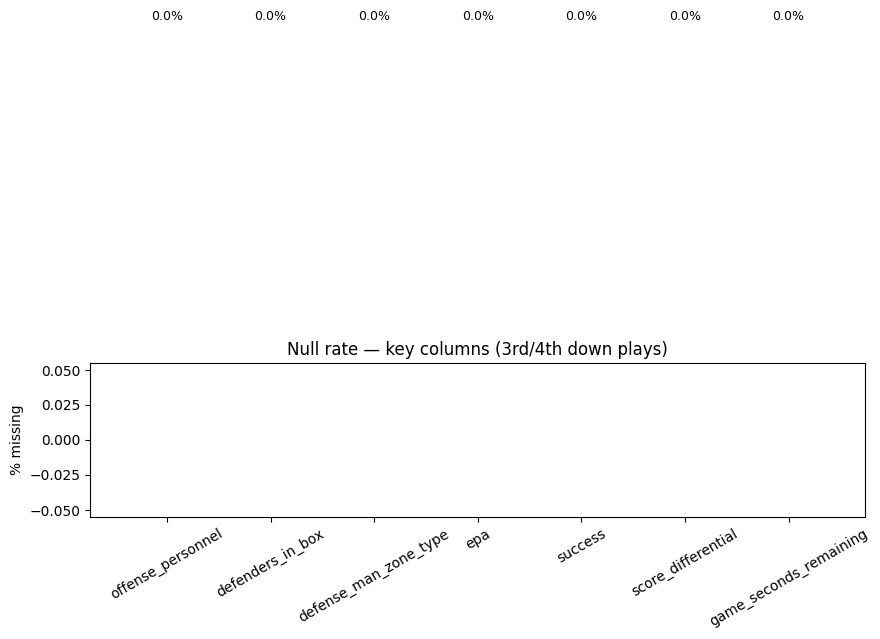

In [10]:
import matplotlib.pyplot as plt

null_pct = pbp.isnull().mean().sort_values(ascending=False) * 100
print("Null rate per column (%):\n")
print(null_pct[null_pct > 0].to_string())

# Visual: missingness heatmap for key columns
key_cols = ["offense_personnel", "defenders_in_box", "defense_man_zone_type",
            "epa", "success", "score_differential",
            "game_seconds_remaining"]
key_cols = [c for c in key_cols if c in pbp.columns]

fig, ax = plt.subplots(figsize=(10, 2))
null_rates = pbp[key_cols].isnull().mean() * 100
bars = ax.bar(key_cols, null_rates, color="steelblue")
ax.set_ylabel("% missing")
ax.set_title("Null rate — key columns (3rd/4th down plays)")
ax.tick_params(axis="x", rotation=30)
for bar, val in zip(bars, null_rates):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f"{val:.1f}%", ha="center", fontsize=9)
plt.show()

### 1.4 Compute Defensive Success Label

The model's target is **defensive success**: the offense failed to gain positive EPA or failed the conversion.

- `def_success = 1` if `epa <= 0` (defense held)
- `def_success = 0` if `epa > 0` (offense gained value)

In [11]:
before = len(pbp)
pbp = pbp.dropna(subset=["epa"]).copy()
dropped = before - len(pbp)
if dropped:
    print(f"Dropped {dropped:,} rows with missing EPA")

pbp["def_success"] = (pbp["epa"] <= 0).astype("int8")
rate = pbp["def_success"].mean()
print(f"Defensive success rate on 3rd/4th down: {rate:.3f}  "
      f"({pbp['def_success'].sum():,} of {len(pbp):,} plays)")

Defensive success rate on 3rd/4th down: 0.584  (7,400 of 12,680 plays)


### 1.4.1 Personnel Package Classification

Map raw personnel strings to bucketed labels used by the model.

**Offense** — keyed on RB + TE counts (FBs counted as RBs):

| Package | RBs | TEs |
|---|---|---|
| `01` | 0 | 1 |
| `02` | 0 | 2 |
| `10` | 1 | 0 |
| `11` | 1 | 1 |
| `12` | 1 | 2 |
| `13` | 1 | 3 |
| `20` | 2 | 0 |
| `21` | 2 | 1 |
| `22` | 2 | 2 |
| `OTHER` | — | — |

`heavy = 1` when more than 5 offensive linemen (C + G + T) are on the field.

**Defense** — keyed on DB count (CB + FS + SS + S):

| Package | DBs | Notes |
|---|---|---|
| `Heavy` | ≤ 3 | goal line and 4-4-3 looks |
| `Base` | 4 | standard 4-3 / 3-4 |
| `Nickel` | 5 | +1 DB sub |
| `Dime` | 6 | +2 DB sub |
| `Quarter` | ≥ 7 | max coverage shell |
| `Other` | — | doesn't fit above |

In [15]:
import re

# ── helpers ──────────────────────────────────────────────────────────────────

def _parse_counts(s):
    """Return {POSITION: count} from a personnel string, or {} if null."""
    if pd.isna(s):
        return {}
    return {pos: int(n) for n, pos in re.findall(r'(\d+)\s+([A-Z]+)', s)}


# ── offensive personnel ───────────────────────────────────────────────────────

_OFF_VALID = {"01", "02", "10", "11", "12", "13", "20", "21", "22"}

def classify_offense(s):
    c = _parse_counts(s)
    if not c:
        return "OTHER"
    rbs = c.get("RB", 0) + c.get("FB", 0)  # FBs count as RBs for personnel
    pkg = f"{rbs}{c.get('TE', 0)}"
    return pkg if pkg in _OFF_VALID else "OTHER"


def is_heavy(s):
    """1 if more than 5 offensive linemen (C + G + T) are on the field."""
    c = _parse_counts(s)
    return int(c.get("C", 0) + c.get("G", 0) + c.get("T", 0) > 5)


# ── defensive personnel ───────────────────────────────────────────────────────

def classify_defense(s):
    c = _parse_counts(s)
    if not c:
        return "OTHER"
    dbs = c.get("CB", 0) + c.get("FS", 0) + c.get("SS", 0) + c.get("S", 0)
    if dbs <= 3:  return "Heavy"   # goal line (≤2 DB) and 4-4-3 (3 DB)
    if dbs == 4:  return "Base"
    if dbs == 5:  return "Nickel"
    if dbs == 6:  return "Dime"
    if dbs >= 7:  return "Quarter"
    return "OTHER"


# ── apply ─────────────────────────────────────────────────────────────────────

pbp["off_personnel"] = pbp["offense_personnel"].apply(classify_offense)
pbp["off_heavy"]     = pbp["offense_personnel"].apply(is_heavy)
pbp["def_personnel"] = pbp["defense_personnel"].apply(classify_defense)

# Home/away indicator for the defending team
pbp["defense_is_home"] = (pbp["defteam"] == pbp["home_team"]).astype("int8")

In [12]:
# QA: snap-level offensive player fields (included via CANONICAL_COLS)
player_fields = [c for c in ["offense_players", "offense_names", "offense_positions"] if c in pbp.columns]
for col in player_fields:
    null_pct = pbp[col].isnull().mean() * 100
    print(f"{col} null rate: {null_pct:.1f}%")

if "offense_names" in pbp.columns and pbp["offense_names"].notna().any():
    example = pbp["offense_names"].dropna().iloc[0]
    print(f"\nExample offense_names: {example}")
if "offense_players" in pbp.columns and pbp["offense_players"].notna().any():
    example = pbp["offense_players"].dropna().iloc[0]
    print(f"Example offense_players (GSIS IDs): {example}")

offense_players null rate: 0.0%
offense_names null rate: 0.0%
offense_positions null rate: 0.0%

Example offense_names: Evan Brown;Hjalte Froholdt;Will Hernandez;Kyler Murray;Emari Demercado;Jonah Williams;Paris Johnson Jr.;Trey McBride;Greg Dortch;Michael Wilson;Marvin Harrison Jr.
Example offense_players (GSIS IDs): 00-0034495;00-0035258;00-0034346;00-0035228;00-0038705;00-0035629;00-0038540;00-0037744;00-0035500;00-0038559;00-0039849


### 1.5 Edge Case Filtering

Remove disguised special-teams plays that survive the initial play-type filter: fake field goals, fake punts, and penalty no-plays (e.g. defensive holding on a FG attempt) that get coded as no_play with a normal down number. Detection is based on offensive personnel -- any snap with a kicker (K), punter (P), or long snapper (LS) in the offensive personnel string is a special-teams play regardless of play_type.

In [13]:
def has_st_personnel(personnel_str):
    """Return True if K, P, or LS appear in the offensive personnel string."""
    if pd.isna(personnel_str):
        return False
    return any(pos in str(personnel_str).upper() for pos in ["K", "P", "LS"])

before = len(pbp)
pbp = pbp[~pbp["offense_personnel"].apply(has_st_personnel)].copy()
removed = before - len(pbp)
print(f"Edge-case ST filter removed {removed} rows  ({before:,} -> {len(pbp):,})")


Edge-case ST filter removed 12 rows  (12,680 -> 12,668)


In [16]:
pbp[pbp["off_personnel"] == "OTHER"]["offense_personnel"].value_counts()

offense_personnel
1 C, 3 G, 1 QB, 1 T, 3 TE, 2 WR          8
1 C, 2 G, 1 QB, 2 T, 3 TE, 2 WR          7
1 C, 2 G, 1 QB, 2 T, 5 WR                2
2 C, 1 G, 1 QB, 2 T, 3 TE, 2 WR          2
1 C, 2 G, 2 QB, 2 T, 3 TE, 1 WR          2
1 C, 1 FB, 2 G, 1 QB, 1 RB, 2 T, 3 TE    2
1 C, 1 G, 1 QB, 3 T, 3 TE, 2 WR          1
1 C, 1 G, 1 QB, 3 T, 5 WR                1
1 C, 3 G, 2 QB, 2 T, 3 TE                1
Name: count, dtype: int64

In [17]:
print("Offensive personnel distribution:")
print(pbp["off_personnel"].value_counts().to_string())
print(f"\nHeavy formation plays: {pbp['off_heavy'].sum():,} ({pbp['off_heavy'].mean()*100:.1f}%)")
print("\nDefensive personnel distribution:")
print(pbp["def_personnel"].value_counts().to_string())

Offensive personnel distribution:
off_personnel
11       10708
12        1233
13         143
21         132
10         123
02         109
01          98
22          60
20          36
OTHER       26

Heavy formation plays: 91 (0.7%)

Defensive personnel distribution:
def_personnel
Nickel     7979
Dime       3940
Base        608
Quarter      81
Heavy        60


### 1.5.1 Filter Integrity Audit

Validate that filtered dataset respects project scope rules.

In [18]:
import random
random.seed(42)

# Sample 150 random rows
sample_size = 150
sample_indices = random.sample(range(len(pbp)), min(sample_size, len(pbp)))
sample_audit = pbp_3rd4th.loc[pbp.index[sample_indices]].copy()

# Criteria checks (from project scope)
criteria = {
    "down in {3, 4}": sample_audit["down"].isin([3, 4]),
    "play_type in {pass, run, no_play}": sample_audit["play_type"].isin({"pass", "run", "no_play"}),
    "no special teams": ~sample_audit["play_type"].isin({"punt", "field_goal", "kickoff"}),
    "no ST-only markers": ~(sample_audit["special_teams_play"].fillna(False).astype(bool)),
}

# has_st_personnel is defined in section 1.5
criteria["no K/P/LS in offense"] = ~sample_audit["offense_personnel"].apply(has_st_personnel)

# Show results
print("=" * 70)
print("AUDIT 1: OVERALL SCOPE INTEGRITY")
print("=" * 70)
print(f"Sample size: {len(sample_audit)} rows")

all_pass = True
for criterion, result in criteria.items():
    pass_count = result.sum()
    pass_pct = 100 * pass_count / len(result)
    status = "✓ PASS" if pass_pct == 100 else "✗ FAIL"
    print(f"{status}  {criterion}: {pass_count}/{len(result)} ({pass_pct:.1f}%)")
    if pass_pct != 100:
        all_pass = False
        print(f"       Failed indices: {sample_audit.index[~result].tolist()[:5]}...")

print(f"Overall: {chr(10003) + " PASS" if all_pass else chr(10007) + " FAIL"}")
print("=" * 70)


AUDIT 1: OVERALL SCOPE INTEGRITY
Sample size: 150 rows
✓ PASS  down in {3, 4}: 150/150 (100.0%)
✓ PASS  play_type in {pass, run, no_play}: 150/150 (100.0%)
✓ PASS  no special teams: 150/150 (100.0%)
✓ PASS  no ST-only markers: 150/150 (100.0%)
✓ PASS  no K/P/LS in offense: 150/150 (100.0%)
Overall: ✓ PASS


### 1.5.2 Penalty Rule Integrity (Focused Audit)

Audit penalty-related plays to verify nuanced rules are applied correctly.

In [19]:
# Build a penalty-focused sample from pbp_raw (before filtering)
penalty_rows = pbp_raw[pbp_raw["penalty"].notna() | pbp_raw["penalty_type"].notna()].copy()

if "penalty_category" not in penalty_rows.columns:
    penalty_rows["penalty_category"] = penalty_rows["penalty_type"].apply(categorize_penalty)

print(f"Total penalty plays in raw data: {len(penalty_rows)}")

if len(penalty_rows) == 0:
    print("No penalty plays found in raw data - skipping penalty audit.")
else:
    focal_cats = {"FOCAL_DEFENSIVE PASS INTERFERENCE", "FOCAL_DEFENSIVE HOLDING", "FOCAL_INTENTIONAL GROUNDING"}

    has_focal = penalty_rows["penalty_category"].isin(focal_cats)
    has_other = penalty_rows["penalty_category"] == "OTHER"
    in_filtered = penalty_rows.index.isin(pbp.index)

    is_st = penalty_rows["offense_personnel"].apply(has_st_personnel)
    is_3rd_4th = penalty_rows["down"].isin([3, 4])
    is_relevant_play = penalty_rows["play_type"].isin(RELEVANT_PLAY_TYPES)
    has_coverage = penalty_rows[["defense_man_zone_type", "defense_coverage_type"]].notna().all(axis=1)
    eligible = is_3rd_4th & is_relevant_play & ~is_st & has_coverage

    focal_eligible = has_focal & eligible
    focal_included_correctly = focal_eligible & in_filtered
    focal_but_excluded = focal_eligible & ~in_filtered

    other_excluded_correctly = has_other & ~in_filtered
    other_but_included = has_other & in_filtered

    print(f"Penalty breakdown in raw data:")
    print(penalty_rows["penalty_category"].value_counts().to_string())
    print(f"Of {has_focal.sum()} focal penalty plays:")
    print(f"  Eligible (3rd/4th, not ST, has coverage): {focal_eligible.sum()}")
    print(f"  Ineligible (wrong down, ST play, or no coverage data): {(has_focal & ~eligible).sum()}")

    print(f"--- FOCAL PENALTY RULES ---")
    print(f"  Should be included: {focal_eligible.sum()}")
    print(f"  Correctly included: {focal_included_correctly.sum()}")
    print(f"  X Missing from filtered set: {focal_but_excluded.sum()}")

    if focal_but_excluded.sum() > 0:
        print(f"  Problem rows: {penalty_rows[focal_but_excluded].index.tolist()[:5]}")
        print(penalty_rows[focal_but_excluded][["down", "play_type", "penalty_type", "offense_personnel"]].head())

    print(f"--- OTHER PENALTY RULES ---")
    print(f"  Should be excluded: {has_other.sum()}")
    print(f"  Correctly excluded: {other_excluded_correctly.sum()}")
    print(f"  X Leaked to filtered set: {other_but_included.sum()}")

    if other_but_included.sum() > 0:
        print(f"  Problem rows: {penalty_rows[other_but_included].index.tolist()[:5]}")

    focal_pass = (focal_but_excluded.sum() == 0)
    other_pass = (other_but_included.sum() == 0)

    print(f"--- AUDIT RESULT ---")
    print(f"Focal penalty inclusion: {chr(10003) + " PASS" if focal_pass else chr(10007) + " FAIL"}")
    print(f"Other penalty exclusion: {chr(10003) + " PASS" if other_pass else chr(10007) + " FAIL"}")
    print("=" * 70)


Total penalty plays in raw data: 95235
Penalty breakdown in raw data:
penalty_category
NONE                                 88051
OTHER                                 6120
FOCAL_DEFENSIVE PASS INTERFERENCE      604
FOCAL_DEFENSIVE HOLDING                367
FOCAL_INTENTIONAL GROUNDING             93
Of 1064 focal penalty plays:
  Eligible (3rd/4th, not ST, has coverage): 380
  Ineligible (wrong down, ST play, or no coverage data): 684
--- FOCAL PENALTY RULES ---
  Should be included: 380
  Correctly included: 380
  X Missing from filtered set: 0
--- OTHER PENALTY RULES ---
  Should be excluded: 6120
  Correctly excluded: 6120
  X Leaked to filtered set: 0
--- AUDIT RESULT ---
Focal penalty inclusion: ✓ PASS
Other penalty exclusion: ✓ PASS


### 1.6 Persist Cleaned Dataset

In [20]:
import os

DATA_DIR = "data"
os.makedirs(DATA_DIR, exist_ok=True)

csv_path = os.path.join(DATA_DIR, "pbp_3rd4th_2024_2025.csv")
pbp.to_csv(csv_path, index=False)

print(f"Saved CSV → {csv_path}")
print(f"Final dataset: {pbp.shape[0]:,} rows × {pbp.shape[1]} columns")
pbp.describe(include="all").T

Saved CSV → data\pbp_3rd4th_2024_2025.csv
Final dataset: 12,668 rows × 34 columns


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
game_id,12668,570,2025_18_LAC_DEN,35,NaN,NaN,NaN,NaN,NaN,NaN,NaN
play_id,12668.0,NaN,NaN,NaN,2207.456543,1267.706665,99.0,1100.75,2228.0,3300.25,5243.0
week,12668.0,NaN,NaN,NaN,10.003394,5.607437,1.0,5.0,10.0,15.0,22.0
posteam,12668,32,HOU,478,NaN,NaN,NaN,NaN,NaN,NaN,NaN
defteam,12668,32,DEN,475,NaN,NaN,NaN,NaN,NaN,NaN,NaN
down,12668.0,NaN,NaN,NaN,3.091569,0.288428,3.0,3.0,3.0,3.0,4.0
ydstogo,12668.0,NaN,NaN,NaN,7.44498,4.745922,1.0,4.0,7.0,10.0,40.0
yardline_100,12668.0,NaN,NaN,NaN,48.029049,23.575857,1.0,30.0,51.0,66.0,99.0
score_differential,12668.0,NaN,NaN,NaN,-2.414904,10.184294,-46.0,-7.0,-1.0,3.0,43.0
game_seconds_remaining,12668.0,NaN,NaN,NaN,1673.937622,1049.960815,2.0,734.0,1713.0,2561.0,3591.0


## 2. Feature Engineering (Week 3)

Add the in-game history window described in the project plan, define the modeling subsets the policy engine will use, and codify the optimization objective. Snap-level player joins for Week 6 use structured **`gsis_id`** from PBP `offense_players` (aligned with `offense_names` / `offense_positions`) — no fuzzy name matching.

### 2.1 In-Game History Features

For each filtered 3rd/4th-down snap, build features from the **last up to 5 prior 3rd/4th conversion attempts** in the same game where the **same team was on defense**. The current play is excluded; early-game rows have a partial or empty window (cold start).

Per-row features:

- `def_seq_idx` — 1-indexed position in this defense's 3rd/4th sequence in the game.
- `hist_n` — number of prior plays in the window (0–5).
- `prev_def_personnel`, `prev_defense_man_zone_type`, `prev_defense_coverage_type` — most recent prior call.
- `same_personnel_as_prev`, `same_manzone_as_prev`, `same_coverage_as_prev` — repetition flags vs the immediately prior call.
- `hist_<bucket>_count` — count of `Nickel` / `Dime` / `Base` / `MAN_COVERAGE` / `ZONE_COVERAGE` in the window.
- `hist_max_personnel_repeat`, `hist_max_manzone_repeat` — most-frequent value's count in the window (proxy for how predictable the recent calls have been).

In [82]:
HISTORY_WINDOW = 5

# Sort so each (game, defense) sequence is well-defined
pbp_sorted = pbp.sort_values(["game_id", "defteam", "play_id"]).copy().reset_index(drop=True)

g = pbp_sorted.groupby(["game_id", "defteam"], sort=False)

# Position in this defense's 3rd/4th sequence in the game (1-indexed)
pbp_sorted["def_seq_idx"] = g.cumcount() + 1

# Lag-1 (most recent prior call) and same-as-prev flags
for col in ["def_personnel", "defense_man_zone_type", "defense_coverage_type"]:
    pbp_sorted[f"prev_{col}"] = g[col].shift(1)

pbp_sorted["same_personnel_as_prev"] = (
    pbp_sorted["def_personnel"] == pbp_sorted["prev_def_personnel"]
).astype("int8")
pbp_sorted["same_manzone_as_prev"] = (
    pbp_sorted["defense_man_zone_type"] == pbp_sorted["prev_defense_man_zone_type"]
).astype("int8")
pbp_sorted["same_coverage_as_prev"] = (
    pbp_sorted["defense_coverage_type"] == pbp_sorted["prev_defense_coverage_type"]
).astype("int8")

# Rolling counts over the last HISTORY_WINDOW PRIOR plays (current row excluded).
# Build indicator columns, then use groupby+transform to do a per-group rolling sum
# of the SHIFTED indicator series.
indicators = {
    "_is_nickel": (pbp_sorted["def_personnel"] == "Nickel"),
    "_is_dime":   (pbp_sorted["def_personnel"] == "Dime"),
    "_is_base":   (pbp_sorted["def_personnel"] == "Base"),
    "_is_man":    (pbp_sorted["defense_man_zone_type"] == "MAN_COVERAGE"),
    "_is_zone":   (pbp_sorted["defense_man_zone_type"] == "ZONE_COVERAGE"),
}
for name, series in indicators.items():
    pbp_sorted[name] = series.astype("int8")

def _rolling_prior(s, window=HISTORY_WINDOW):
    return s.shift(1).rolling(window=window, min_periods=1).sum().fillna(0)

g = pbp_sorted.groupby(["game_id", "defteam"], sort=False)
for src, dst in [
    ("_is_nickel", "hist_nickel_count"),
    ("_is_dime",   "hist_dime_count"),
    ("_is_base",   "hist_base_count"),
    ("_is_man",    "hist_man_count"),
    ("_is_zone",   "hist_zone_count"),
]:
    pbp_sorted[dst] = g[src].transform(_rolling_prior).astype("int16")

pbp_sorted["hist_n"] = (pbp_sorted["def_seq_idx"] - 1).clip(upper=HISTORY_WINDOW).astype("int8")
pbp_sorted["hist_max_personnel_repeat"] = pbp_sorted[
    ["hist_nickel_count", "hist_dime_count", "hist_base_count"]
].max(axis=1).astype("int16")
pbp_sorted["hist_max_manzone_repeat"] = pbp_sorted[
    ["hist_man_count", "hist_zone_count"]
].max(axis=1).astype("int16")

# Drop the scratch indicator columns
pbp_sorted = pbp_sorted.drop(columns=list(indicators.keys()))

print(f"History features attached. Shape: {pbp_sorted.shape}")
print(f"Cold-start rows (hist_n == 0): {(pbp_sorted['hist_n'] == 0).sum():,} "
      f"({(pbp_sorted['hist_n'] == 0).mean() * 100:.1f}%)")
print(f"\nMean repeat-of-prev rates (1.0 = always repeats the immediately prior call):")
print(f"  same_personnel_as_prev: {pbp_sorted['same_personnel_as_prev'].mean():.3f}")
print(f"  same_manzone_as_prev:   {pbp_sorted['same_manzone_as_prev'].mean():.3f}")
print(f"  same_coverage_as_prev:  {pbp_sorted['same_coverage_as_prev'].mean():.3f}")

History features attached. Shape: (12668, 40)
Cold-start rows (hist_n == 0): 1,140 (9.0%)

Mean repeat-of-prev rates (1.0 = always repeats the immediately prior call):
  same_personnel_as_prev: 0.621
  same_manzone_as_prev:   0.492
  same_coverage_as_prev:  0.236


In [84]:
# Show one full game/defense sequence so the history features are easy to eyeball
sample_game = pbp_sorted["game_id"].iloc[0]
sample_def  = pbp_sorted.loc[pbp_sorted["game_id"] == sample_game, "defteam"].iloc[0]

display_cols = [
    "play_id", "down", "ydstogo",
    "def_personnel", "defense_man_zone_type", "defense_coverage_type",
    "def_seq_idx", "hist_n",
    "prev_def_personnel", "same_personnel_as_prev",
    "hist_nickel_count", "hist_dime_count", "hist_man_count", "hist_zone_count",
]
mask = (pbp_sorted["game_id"] == sample_game) & (pbp_sorted["defteam"] == sample_def)
print(f"Example sequence -- game {sample_game}, defense {sample_def}")
pbp_sorted.loc[mask, display_cols]

Example sequence -- game 2024_01_ARI_BUF, defense ARI


,play_id,down,ydstogo,def_personnel,defense_man_zone_type,defense_coverage_type,def_seq_idx,hist_n,prev_def_personnel,same_personnel_as_prev,hist_nickel_count,hist_dime_count,hist_man_count,hist_zone_count
0,1093.0,3.0,19.0,Dime,ZONE_COVERAGE,COVER_9,1,0,NaN,0,0,0,0,0
1,1646.0,3.0,6.0,Nickel,ZONE_COVERAGE,COVER_3,2,1,Dime,0,0,1,0,1
2,2060.0,3.0,11.0,Nickel,MAN_COVERAGE,COVER_1,3,2,Nickel,1,1,1,0,2
3,2216.0,3.0,10.0,Nickel,MAN_COVERAGE,COVER_0,4,3,Nickel,1,2,1,1,2
4,2445.0,3.0,7.0,Nickel,MAN_COVERAGE,COVER_1,5,4,Nickel,1,3,1,2,2
5,3099.0,3.0,14.0,Dime,ZONE_COVERAGE,COVER_3,6,5,Nickel,0,4,1,3,2
6,3124.0,4.0,2.0,Nickel,MAN_COVERAGE,COVER_1,7,5,Dime,0,4,1,3,2
7,3498.0,3.0,6.0,Nickel,MAN_COVERAGE,COVER_1,8,5,Nickel,1,4,1,4,1


### 2.2 Modeling Subsets

- **`core_set`** — every filtered play with baseline situational + offensive personnel features. Used for broad models that don't need full defensive detail.
- **`rich_set`** — subset with **complete defensive-detail labels** (`def_personnel`, `defenders_in_box`, `defense_man_zone_type`, `defense_coverage_type`). Used by the policy engine, which needs to score discrete defensive actions.

Coverage labels are already enforced at ingestion (Section 1.2), so the two sets only diverge where `defenders_in_box` is missing or the personnel string falls into `OTHER`.

In [85]:
core_set = pbp_sorted.copy()

VALID_DEF_PACKAGES = {"Base", "Nickel", "Dime", "Heavy", "Quarter"}
VALID_MANZONE      = {"MAN_COVERAGE", "ZONE_COVERAGE"}

rich_mask = (
    pbp_sorted["defenders_in_box"].notna()
    & pbp_sorted["def_personnel"].isin(VALID_DEF_PACKAGES)
    & pbp_sorted["defense_man_zone_type"].isin(VALID_MANZONE)
    & pbp_sorted["defense_coverage_type"].notna()
)
rich_set = pbp_sorted[rich_mask].copy()

print(f"core_set: {len(core_set):,} rows")
print(f"rich_set: {len(rich_set):,} rows  "
      f"({len(rich_set) / len(core_set) * 100:.1f}% of core)")
print(f"\nrich_set defense_personnel distribution:")
print(rich_set["def_personnel"].value_counts().to_string())

core_set: 12,668 rows
rich_set: 12,668 rows  (100.0% of core)

rich_set defense_personnel distribution:
def_personnel
Nickel     7979
Dime       3940
Base        608
Quarter      81
Heavy        60


### 2.3 Optimization Objective

The policy engine (Weeks 4–5) scores a **finite set of candidate defensive actions** at every decision point. Defining the candidate space and scoring rule now keeps the modeling target concrete.

A **candidate action** is a tuple `(def_personnel, defense_coverage_type)` that appears at least `MIN_CANDIDATE_COUNT` times in `rich_set`. `defense_man_zone_type` is excluded because it is perfectly determined by `defense_coverage_type` (Cramér's V = 1.0, confirmed in `analyze_manzone_coverage_correlation.py`) and adds zero information to the model. It is retained in the candidates DataFrame for human-readable output only. Rare tuples are dropped to limit noise; this can be relaxed later if coverage suffers.

**Composite objective** (lower is better, defense's POV):

$$\text{score}(a \mid s, h) \;=\; \widehat{E}[\text{EPA} \mid s, a] \;+\; \lambda \cdot \text{repeat}(a, h)$$

- $\widehat{E}[\text{EPA} \mid s, a]$ — model estimate of offensive EPA given state $s$ and candidate action $a$ (filled in once outcome models exist).
- $\text{repeat}(a, h)$ — count of plays in the history window $h$ (last 5) whose `coverage_type` matches $a$.
- $\lambda$ — tunable predictability weight.

**Decision rule** in `select_action`:
1. Find every candidate within `narrow_band` EPA of the predicted minimum.
2. If exactly one candidate is in the band, take it — a clear EPA winner is **not** overridden by predictability.
3. Otherwise apply $\lambda$ and pick the candidate with the lowest composite score.

This satisfies the plan's requirement that the predictability penalty only acts when EPA cannot decide.

In [106]:
MIN_CANDIDATE_COUNT = 20  # tunable; drop very rare tuples to limit noise

CANDIDATE_KEYS = ["def_personnel", "defense_man_zone_type", "defense_coverage_type"]

candidates = (
    rich_set.groupby(CANDIDATE_KEYS, observed=True)
    .agg(count=("epa", "size"),
         mean_off_epa=("epa", "mean"),
         def_success_rate=("def_success", "mean"))
    .reset_index()
)
candidates = (
    candidates[candidates["count"] >= MIN_CANDIDATE_COUNT]
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)
candidates["action_id"] = range(len(candidates))

print(f"Candidate action space: {len(candidates)} tuples "
      f"(min count = {MIN_CANDIDATE_COUNT})")
print(f"Coverage of rich_set: "
      f"{candidates['count'].sum()} / {len(rich_set)} rows "
      f"({candidates['count'].sum() / len(rich_set) * 100:.1f}%)")
candidates.head(15)

Candidate action space: 26 tuples (min count = 20)
Coverage of rich_set: 12562 / 12668 rows (99.2%)


,def_personnel,defense_man_zone_type,defense_coverage_type,count,mean_off_epa,def_success_rate,action_id
0,Nickel,MAN_COVERAGE,COVER_1,2977,0.061267,0.548539,0
1,Nickel,ZONE_COVERAGE,COVER_3,1512,-0.070473,0.596561,1
2,Nickel,ZONE_COVERAGE,COVER_2,1502,-0.084806,0.605193,2
3,Dime,MAN_COVERAGE,COVER_1,1333,0.087464,0.575394,3
4,Dime,ZONE_COVERAGE,COVER_2,749,-0.125263,0.636849,4
5,Dime,ZONE_COVERAGE,COVER_3,640,0.013169,0.645312,5
6,Nickel,ZONE_COVERAGE,COVER_4,561,0.020073,0.614973,6
7,Dime,MAN_COVERAGE,2_MAN,527,0.005790,0.601518,7
8,Nickel,MAN_COVERAGE,COVER_0,503,0.224047,0.558648,8
9,Nickel,MAN_COVERAGE,2_MAN,425,0.061629,0.583529,9


In [107]:
def policy_score(epa_pred, candidate, recent_history, lambda_pred):
    """Composite score (lower is better for defense).

    candidate         : Series/dict with at least 'defense_coverage_type'.
    recent_history    : iterable of dicts/Series describing the last <=5 prior
                        plays for this defense (most recent last).
    Repeat keyed on coverage_type only; defense_man_zone_type is perfectly
    determined by coverage_type and adding it is redundant.
    """
    repeat = sum(
        1 for h in recent_history
        if h.get("defense_coverage_type") == candidate["defense_coverage_type"]
    )
    return float(epa_pred) + lambda_pred * repeat


def select_action(epa_predictions, candidates_df, recent_history,
                  lambda_pred=0.05, narrow_band=0.10):
    """Pick the candidate index with the best composite score.

    1. Find candidates within `narrow_band` EPA of the predicted minimum.
    2. If only one candidate is in the band, return it (clear EPA winner --
       predictability penalty does not override).
    3. Otherwise apply the predictability penalty and pick the lowest scorer.
    """
    epa_predictions = np.asarray(epa_predictions, dtype=float)
    if len(epa_predictions) != len(candidates_df):
        raise ValueError("epa_predictions length must match number of candidates")

    best = epa_predictions.min()
    in_band = np.where(epa_predictions <= best + narrow_band)[0]

    if len(in_band) == 1:
        return int(in_band[0])

    scored = [
        (i, policy_score(epa_predictions[i], candidates_df.iloc[i],
                         recent_history, lambda_pred))
        for i in in_band
    ]
    return int(min(scored, key=lambda x: x[1])[0])

### 2.4 Policy Engine Demo

This cell exercises the full policy API end-to-end using randomly generated EPA predictions as stand-ins for the outcome model that will be built in Weeks 4–5. It selects the best candidate action twice — once with no predictability penalty (`lambda = 0`) and once with a small penalty (`lambda = 0.10`) — to verify that the tie-break logic works and that repeated schemes are correctly penalized when the EPA difference is within `narrow_band`. The demo uses a real game sequence from `rich_set` so the recent-history context is grounded in actual play-by-play data.

In [108]:
# Demo: score the candidate set against placeholder EPA predictions (random).
# Real EPA models arrive in Weeks 4-5; this just exercises the policy API.
rng = np.random.default_rng(0)
mock_epa = rng.normal(loc=0.0, scale=0.5, size=len(candidates))

# Pick a row deep enough into a game to have non-trivial recent history
demo_row = rich_set[rich_set["def_seq_idx"] >= 4].iloc[0]
demo_game, demo_def = demo_row["game_id"], demo_row["defteam"]

prior = (
    rich_set[(rich_set["game_id"] == demo_game)
             & (rich_set["defteam"] == demo_def)
             & (rich_set["play_id"] < demo_row["play_id"])]
    .sort_values("play_id")
    .tail(HISTORY_WINDOW)
)
recent_history = prior[
    ["def_personnel", "defense_coverage_type"]
].to_dict("records")

choice_no_pen = select_action(mock_epa, candidates, recent_history,
                              lambda_pred=0.0)
choice_pen    = select_action(mock_epa, candidates, recent_history,
                              lambda_pred=0.10, narrow_band=0.10) # higher lambda_pred, narrow_band produce different results

print(f"Demo decision -- game {demo_game}, defense {demo_def}, play {int(demo_row['play_id'])}")
print(f"Recent history (last {len(recent_history)}):")
for h in recent_history:
    print(f"  {h['def_personnel']:>7s}  {h['defense_coverage_type']}")

print(f"\nlambda = 0.00  (pure EPA): {candidates.iloc[choice_no_pen][CANDIDATE_KEYS].to_dict()}"
      f"  mock_epa = {mock_epa[choice_no_pen]:+.3f}")
print(f"lambda = 0.10  (with pen): {candidates.iloc[choice_pen][CANDIDATE_KEYS].to_dict()}"
      f"  mock_epa = {mock_epa[choice_pen]:+.3f}")

Demo decision -- game 2024_01_ARI_BUF, defense ARI, play 2216
Recent history (last 3):
     Dime  COVER_9
   Nickel  COVER_3
   Nickel  COVER_1

lambda = 0.00  (pure EPA): {'def_personnel': 'Base', 'defense_man_zone_type': 'MAN_COVERAGE', 'defense_coverage_type': 'COVER_1'}  mock_epa = -1.163
lambda = 0.10  (with pen): {'def_personnel': 'Base', 'defense_man_zone_type': 'MAN_COVERAGE', 'defense_coverage_type': 'COVER_1'}  mock_epa = -1.163


## 3. Quantitative Policy Engine (Weeks 4-5)

Build the outcome model that turns the candidate action space from Section 2.3 into concrete defensive recommendations.

**Objective.** For every decision point, estimate $\widehat{E}[\text{EPA} \mid s, a, h]$ for each candidate action $a$, then minimize the composite policy score from Section 2.3 (EPA plus the conditional predictability penalty). The deliverable is *not* a model that predicts what NFL defenses usually call &mdash; it is a model whose recommendations beat a down-distance-field bucket baseline on EPA.

**Architecture.** Random Forest regressor over `[state_features + action_components]`. Each play is one training row using its actually-called action; at inference, every candidate is scored by re-predicting with that candidate's components substituted in. RF is robust to mixed types and the ~12k row dataset, and it gives feature importances for the model card.

**Held-out games.** A whole-season holdout (2024 train / 2025 test where both seasons are present) so test games never share a venue, schedule, or roster snapshot with train.

**Limitations** &mdash; documented in detail in Section 3.7:
- Observational data: estimates are conditional means, not causal effects of the call.
- No individual-skill awareness in the tabular layer (qualitative layer in Week 6 fills this).
- Predictability term is a same-game repetition proxy, not a mixed-strategy optimum.

### 3.1 Train / Validation / Test Split (held-out games)

Three-way chronological split so model selection and final reporting never touch each other's data:

| Split | Data | Purpose |
|---|---|---|
| **Train** | All 2024 games + 2025 weeks 1–10 | Fit RF and bucket baseline |
| **Validation** | 2025 weeks 11–15 | Tune $\lambda$, narrow_band, and candidate-set pruning |
| **Test** | 2025 weeks 16+ | Final held-out evaluation only |

Splitting on full games (not individual plays) ensures no game leaks across splits. Time always runs forward: val games are strictly after train; test games are strictly after val.

In [109]:
def _season_from_game_id(gid):
    return int(str(gid).split("_", 1)[0])

rich_set["season"] = rich_set["game_id"].apply(_season_from_game_id)

train_mask = (rich_set["season"] == 2024) | (
    (rich_set["season"] == 2025) & (rich_set["week"] <= 10)
)
val_mask  = (rich_set["season"] == 2025) & (rich_set["week"].between(11, 15))
test_mask = (rich_set["season"] == 2025) & (rich_set["week"] >= 16)

train_df = rich_set[train_mask].copy().reset_index(drop=True)
val_df   = rich_set[val_mask].copy().reset_index(drop=True)
test_df  = rich_set[test_mask].copy().reset_index(drop=True)

print("Split summary:")
print(f"  train : {len(train_df):,} rows  ({train_df['game_id'].nunique():,} games)  "
      f"2024 all + 2025 wk 1-10")
print(f"  val   : {len(val_df):,} rows  ({val_df['game_id'].nunique():,} games)  "
      f"2025 wk 11-15")
print(f"  test  : {len(test_df):,} rows  ({test_df['game_id'].nunique():,} games)  "
      f"2025 wk 16+")

Split summary:
  train : 9,618 rows  (434 games)  2024 all + 2025 wk 1-10
  val   : 1,669 rows  (75 games)  2025 wk 11-15
  test  : 1,381 rows  (61 games)  2025 wk 16+


### 3.2 Feature Set

**State features** $s$ (what the defense knows before the snap):
- Situational: `down`, `ydstogo`, `yardline_100`, `score_differential`, `game_seconds_remaining`.
- Offense personnel grouping (`off_personnel`).
- In-game history features from Section 2.1 (`def_seq_idx`, `hist_n`, the rolling counts, the same-as-prev flags).

**Action features** $a$: the two modeled components of the candidate tuple (`def_personnel`, `defense_coverage_type`), with `defense_man_zone_type` retained for readability only because it is perfectly determined by coverage type in this dataset. Encoding components separately rather than as a single `action_id` lets the RF generalise across tuples that share a component (e.g. all `Dime` calls).

Rows whose called action is **not** in the candidate set are dropped so train and test only contain actions the policy can recommend &mdash; this keeps training-target distribution and inference-time scoring distribution aligned. `defenders_in_box` is intentionally excluded from state features in v0; a future version can test adding **bucketed** box count as an action-space refinement if candidate coverage and calibration remain stable.

In [110]:
NUMERIC_STATE_FEATURES = [
    "down", "ydstogo", "yardline_100", "score_differential",
    "game_seconds_remaining",
    "def_seq_idx", "hist_n",
    "hist_nickel_count", "hist_dime_count", "hist_base_count",
    "hist_man_count", "hist_zone_count",
    "hist_max_personnel_repeat", "hist_max_manzone_repeat",
    "same_personnel_as_prev", "same_manzone_as_prev", "same_coverage_as_prev",
]
CATEGORICAL_STATE_FEATURES = ["off_personnel"]
ACTION_COMPONENTS = ["def_personnel", "defense_coverage_type"]  # defense_man_zone_type omitted: perfectly determined by coverage_type (Cramer's V = 1.0)

ALL_CATEGORICAL = CATEGORICAL_STATE_FEATURES + ACTION_COMPONENTS
ALL_FEATURES    = NUMERIC_STATE_FEATURES + ALL_CATEGORICAL

# Restrict rows to the candidate action set (Section 2.3).
candidate_tuples = set(
    candidates[CANDIDATE_KEYS].itertuples(index=False, name=None)
)

def _in_candidate_set(df):
    keys = list(zip(df["def_personnel"], df["defense_man_zone_type"], df["defense_coverage_type"]))
    return pd.Series([k in candidate_tuples for k in keys], index=df.index)

train_df = train_df[_in_candidate_set(train_df)].reset_index(drop=True)
val_df   = val_df[_in_candidate_set(val_df)].reset_index(drop=True)
test_df  = test_df[_in_candidate_set(test_df)].reset_index(drop=True)

# Map called-action tuple -> action_id for evaluation.
action_lookup = candidates.set_index(CANDIDATE_KEYS)["action_id"]
def _attach_action_id(df):
    keys = list(zip(df["def_personnel"], df["defense_man_zone_type"], df["defense_coverage_type"]))
    df = df.copy()
    df["action_id"] = action_lookup.loc[keys].values
    return df
train_df = _attach_action_id(train_df)
val_df   = _attach_action_id(val_df)
test_df  = _attach_action_id(test_df)

print(f"After candidate-set filter:")
print(f"  train={len(train_df):,}, val={len(val_df):,}, test={len(test_df):,}")
print(f"Numeric state features: {len(NUMERIC_STATE_FEATURES)}; categorical: {len(ALL_CATEGORICAL)}")

After candidate-set filter:
  train=9,537, val=1,652, test=1,373
Numeric state features: 17; categorical: 3


### 3.3 Down-Distance-Field Bucket Baseline

Required by the project plan: an action-conditional baseline that predicts EPA from coarse situational buckets only. The policy model has to beat this to earn its complexity.

Buckets:
- `down_b`: 3 vs 4.
- `ydstogo_b`: `short` (<=2), `med-short` (3-5), `med-long` (6-10), `long` (11+).
- `yardline_b`: `opp_rz` (<=20), `opp_field` (20-50), `own_field` (50-80), `own_rz` (80+).

The baseline lookup is `mean(EPA)` over training rows in each (`down_b`, `ydstogo_b`, `yardline_b`, `action_id`) bucket. Falls back to per-action global mean, then overall global mean.

In [114]:
YDSTOGO_BINS   = [-0.1, 2, 5, 10, 100]
YDSTOGO_LABELS = ["short", "med-short", "med-long", "long"]
YARDLINE_BINS   = [-0.1, 20, 50, 80, 101]
YARDLINE_LABELS = ["opp_rz", "opp_field", "own_field", "own_rz"]

def _bucket(df):
    return pd.DataFrame({
        "down_b":     df["down"].astype(int).astype(str),
        "ydstogo_b":  pd.cut(df["ydstogo"],     YDSTOGO_BINS,  labels=YDSTOGO_LABELS).astype(str),
        "yardline_b": pd.cut(df["yardline_100"], YARDLINE_BINS, labels=YARDLINE_LABELS).astype(str),
    })

_train_b = _bucket(train_df)
_train_w = train_df.assign(**_train_b)

bucket_action_lookup = (
    _train_w.groupby(["down_b", "ydstogo_b", "yardline_b", "action_id"], observed=True)["epa"]
    .mean().to_dict()
)
action_global_epa = _train_w.groupby("action_id")["epa"].mean().to_dict()
overall_global_epa = float(train_df["epa"].mean())

def bucket_predict_for_action(df, action_id):
    """Predicted EPA for a single action_id at every row of df."""
    b = _bucket(df)
    out = np.empty(len(df), dtype=float)
    for i, (db, yb, ylb) in enumerate(zip(b["down_b"], b["ydstogo_b"], b["yardline_b"])):
        out[i] = bucket_action_lookup.get(
            (db, yb, ylb, action_id),
            action_global_epa.get(action_id, overall_global_epa),
        )
    return out

def bucket_predict_called(df):
    """Predicted EPA at each row using that row's actually-called action_id."""
    b = _bucket(df)
    out = np.empty(len(df), dtype=float)
    aids = df["action_id"].values
    for i, (db, yb, ylb, aid) in enumerate(zip(b["down_b"], b["ydstogo_b"], b["yardline_b"], aids)):
        out[i] = bucket_action_lookup.get(
            (db, yb, ylb, aid),
            action_global_epa.get(aid, overall_global_epa),
        )
    return out

print(f"Bucket baseline: {len(bucket_action_lookup):,} populated (state-bucket, action) cells")
print(f"Overall train mean EPA: {overall_global_epa:+.4f}")

Bucket baseline: 517 populated (state-bucket, action) cells
Overall train mean EPA: +0.0221


### 3.4 Random Forest EPA Model

Single regressor over `[state, action]`. Categorical features are one-hot encoded; numerics pass through. `min_samples_leaf=20` keeps leaves population-stable given the EPA noise floor.

In [115]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error

def build_xy(df):
    X = df[ALL_FEATURES].copy()
    for c in NUMERIC_STATE_FEATURES:
        X[c] = X[c].astype(float).fillna(0.0)
    for c in ALL_CATEGORICAL:
        X[c] = X[c].astype("string").fillna("NA")
    y = df["epa"].astype(float).values
    return X, y

X_train, y_train = build_xy(train_df)
X_val,   y_val   = build_xy(val_df)
X_test,  y_test  = build_xy(test_df)  # built here for downstream use; not reported until 3.5

preproc = ColumnTransformer(transformers=[
    ("num", "passthrough", NUMERIC_STATE_FEATURES),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), ALL_CATEGORICAL),
])

rf_model = Pipeline([
    ("preproc", preproc),
    ("rf", RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=20,
        n_jobs=-1,
        random_state=0,
    )),
])

rf_model.fit(X_train, y_train)
y_pred_train = rf_model.predict(X_train)
y_pred_val   = rf_model.predict(X_val)

print(f"Random Forest fit on {len(X_train):,} rows")
print(f"  Train: MAE={mean_absolute_error(y_train, y_pred_train):.4f}  "
      f"RMSE={np.sqrt(mean_squared_error(y_train, y_pred_train)):.4f}")
print(f"  Val  : MAE={mean_absolute_error(y_val, y_pred_val):.4f}  "
      f"RMSE={np.sqrt(mean_squared_error(y_val, y_pred_val)):.4f}")

Random Forest fit on 9,537 rows
  Train: MAE=1.5303  RMSE=1.8392
  Val  : MAE=1.7492  RMSE=2.1011


### 3.4.1 Cross-validation Strategy

Standard random k-fold CV is wrong here: plays from the same game would appear in both train and validation folds, and the history features (Section 2.1) would leak future in-game context. Instead we use a **game-blocked, forward-chaining CV** within `train_df`:

1. Sort all training games chronologically (season → week → game).
2. Divide them into `N_CV_FOLDS` contiguous time blocks of equal size.
3. Fold $k$ trains on blocks $0 \ldots k-1$ and validates on block $k$ (expanding window). No game is split across train and validation within a fold.

The CV loop scores each hyperparameter combination by **validation MAE** averaged across folds, then the winning combination is refit on all of `train_df`.

In [119]:
from sklearn.metrics import mean_absolute_error as _mae

N_CV_FOLDS = 5

# Build ordered game list and assign each game a fold index (0 to N_CV_FOLDS-1).
game_order = (
    train_df[["game_id", "season", "week"]]
    .drop_duplicates("game_id")
    .sort_values(["season", "week", "game_id"])
    .reset_index(drop=True)
)
game_order["fold"] = (game_order.index * N_CV_FOLDS // len(game_order)).astype(int)
game_to_fold = game_order.set_index("game_id")["fold"].to_dict()
train_df["_fold"] = train_df["game_id"].map(game_to_fold)

print(f"Training games: {len(game_order):,}")
print("Fold sizes (games):")
print(game_order["fold"].value_counts().sort_index().to_string())

# Hyperparameter grid — small enough to finish in ~2 min.
# n_estimators is fixed at 300 (more trees rarely hurts; tune regularization instead).
# max_features controls per-split feature sampling — the primary RF diversity lever,
# often more impactful than max_depth or min_samples_leaf on noisy targets like EPA.
PARAM_GRID = [
    {"min_samples_leaf": msl, "max_depth": md_, "max_features": mf}
    for msl in [5, 10, 20, 50]
    for md_ in [None, 15, 30]
    for mf in ["sqrt", 0.3, 0.5, 1.0]
]

print(f"Grid size: {len(PARAM_GRID)} combinations x {N_CV_FOLDS} folds = "
      f"{len(PARAM_GRID) * N_CV_FOLDS} fits")

Training games: 434
Fold sizes (games):
fold
0    87
1    87
2    87
3    87
4    86
Grid size: 48 combinations x 5 folds = 240 fits


In [120]:
from sklearn.pipeline import clone as _clone

cv_results = []

for params in PARAM_GRID:
    fold_maes = []
    for val_fold in range(N_CV_FOLDS):
        tr_mask = train_df["_fold"] < val_fold
        vl_mask = train_df["_fold"] == val_fold
        if tr_mask.sum() == 0:
            continue  # skip fold 0 (no training data before it)
        X_tr, y_tr = build_xy(train_df[tr_mask])
        X_vl, y_vl = build_xy(train_df[vl_mask])
        m = _clone(rf_model)
        m.named_steps["rf"].set_params(n_estimators=300, **params)
        m.fit(X_tr, y_tr)
        fold_maes.append(_mae(y_vl, m.predict(X_vl)))
    cv_results.append({
        **params,
        "mean_val_mae": float(np.mean(fold_maes)),
        "std_val_mae":  float(np.std(fold_maes)),
        "n_folds":      len(fold_maes),
    })

cv_df = (
    pd.DataFrame(cv_results)
    .sort_values("mean_val_mae")
    .reset_index(drop=True)
)
print("CV results (sorted by mean validation MAE):")
print(cv_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

CV results (sorted by mean validation MAE):
 min_samples_leaf  max_depth max_features  mean_val_mae  std_val_mae  n_folds
               50    30.0000       1.0000        1.7140       0.0155        4
               50        NaN       1.0000        1.7140       0.0155        4
               50    15.0000       1.0000        1.7140       0.0155        4
               50    15.0000       0.5000        1.7140       0.0163        4
               50        NaN       0.5000        1.7141       0.0163        4
               50    30.0000       0.5000        1.7141       0.0163        4
               50    30.0000       0.3000        1.7151       0.0170        4
               50        NaN       0.3000        1.7151       0.0170        4
               50    15.0000       0.3000        1.7152       0.0170        4
               20    15.0000       0.3000        1.7166       0.0155        4
               20    15.0000         sqrt        1.7166       0.0168        4
               50   

### 3.4.2 Best Hyperparameters and Final Refit

Select the parameter combination with the lowest mean validation MAE and refit on all of `train_df`. This replaces the default `rf_model` from 3.4 so all downstream evaluation (Section 3.5 onward) uses the tuned model.

In [121]:
best = cv_df.iloc[0]
best_params = {
    "min_samples_leaf": int(best["min_samples_leaf"]),
    "max_depth": None if pd.isna(best["max_depth"]) else int(best["max_depth"]),
}
print(f"Best params: {best_params}")
print(f"  CV MAE: {best['mean_val_mae']:.4f} +/- {best['std_val_mae']:.4f}")

# Refit on the full training set with the selected hyperparameters.
rf_model.named_steps["rf"].set_params(n_estimators=300, **best_params)
rf_model.fit(X_train, y_train)  # X_train / y_train built in 3.4

y_pred_train = rf_model.predict(X_train)
y_pred_val   = rf_model.predict(X_val)

print(f"Refit on full train_df ({len(X_train):,} rows):")
print(f"  Train MAE={mean_absolute_error(y_train, y_pred_train):.4f}  "
      f"RMSE={np.sqrt(mean_squared_error(y_train, y_pred_train)):.4f}")
print(f"  Val   MAE={mean_absolute_error(y_val,   y_pred_val):.4f}  "
      f"RMSE={np.sqrt(mean_squared_error(y_val,   y_pred_val)):.4f}")

train_df = train_df.drop(columns=["_fold"])  # clean up scratch column

Best params: {'min_samples_leaf': 50, 'max_depth': 30}
  CV MAE: 1.7140 +/- 0.0155
Refit on full train_df (9,537 rows):
  Train MAE=1.6290  RMSE=1.9488
  Val   MAE=1.7517  RMSE=2.0994


### 3.5 Held-out Evaluation

Three families of metrics on the held-out games:

1. **Regression error** (lower better) &mdash; predicted vs realized EPA on the actually-called action. RF should beat the bucket baseline.
2. **Candidate ranking** &mdash; for every test row, score *all* candidate actions; report the mean rank the actually-called action receives under the model. This is a sanity check that called actions are plausible under the ranking; it is **not** a measure of policy optimality (the data does not contain a ground-truth optimum).
3. **Regret proxy** &mdash; the historical (training) mean EPA of the model's recommended action vs the actually-called action. More-negative is better for the defense.

Caveat: the regret proxy uses *historical* per-action mean EPA as the value of an action, which carries the same observational bias as the policy itself (action-selection effects). It is reported as a sanity check rather than a causal estimate.

In [123]:
# (a) Regression error on actually-called action
y_pred_test = rf_model.predict(X_test)
bucket_test_pred = bucket_predict_called(test_df)

rf_mae   = mean_absolute_error(y_test, y_pred_test)
bk_mae   = mean_absolute_error(y_test, bucket_test_pred)
rf_rmse  = np.sqrt(mean_squared_error(y_test, y_pred_test))
bk_rmse  = np.sqrt(mean_squared_error(y_test, bucket_test_pred))

print("Regression error on held-out games (lower better):")
print(f"  RF     : MAE={rf_mae:.4f}  RMSE={rf_rmse:.4f}")
print(f"  Bucket : MAE={bk_mae:.4f}  RMSE={bk_rmse:.4f}")
delta_mae_pct = (bk_mae - rf_mae) / bk_mae * 100
print(f"  RF improvement vs bucket: {delta_mae_pct:+.1f}% MAE")

Regression error on held-out games (lower better):
  RF     : MAE=1.7180  RMSE=2.0769
  Bucket : MAE=1.7305  RMSE=2.1208
  RF improvement vs bucket: +0.7% MAE


In [124]:
# (b) Score every candidate at every test row
def score_all_candidates(df, model, candidates_df):
    """Return (n_rows, n_candidates) RF EPA predictions."""
    n_state = len(df)
    n_act   = len(candidates_df)
    rep = df.loc[df.index.repeat(n_act)].reset_index(drop=True)
    act_block = pd.concat([candidates_df[CANDIDATE_KEYS]] * n_state, ignore_index=True)
    rep[ACTION_COMPONENTS] = act_block[ACTION_COMPONENTS].values
    X = rep[ALL_FEATURES].copy()
    for c in NUMERIC_STATE_FEATURES:
        X[c] = X[c].astype(float).fillna(0.0)
    for c in ALL_CATEGORICAL:
        X[c] = X[c].astype("string").fillna("NA")
    return model.predict(X).reshape(n_state, n_act)

epa_rf_full = score_all_candidates(test_df, rf_model, candidates)

# Bucket baseline scores for every candidate at every test row
bucket_full = np.column_stack([
    bucket_predict_for_action(test_df, aid) for aid in candidates["action_id"]
])

print(f"Candidate score matrix: RF={epa_rf_full.shape}, Bucket={bucket_full.shape}")

Candidate score matrix: RF=(1373, 26), Bucket=(1373, 26)


In [125]:
# (c) Rank of called action under each model (1 = top recommendation)
called = test_df["action_id"].values
rank_rf = (epa_rf_full.argsort(axis=1).argsort(axis=1))[np.arange(len(test_df)), called] + 1
rank_bk = (bucket_full.argsort(axis=1).argsort(axis=1))[np.arange(len(test_df)), called] + 1

print(f"Mean rank of actually-called action  (out of {len(candidates)} candidates):")
print(f"  RF    : {rank_rf.mean():.2f}   median = {np.median(rank_rf):.0f}")
print(f"  Bucket: {rank_bk.mean():.2f}   median = {np.median(rank_bk):.0f}")
print()
print(f"Top-3 hit rate (called action is in model's top 3):")
print(f"  RF    : {(rank_rf <= 3).mean()*100:.1f}%")
print(f"  Bucket: {(rank_bk <= 3).mean()*100:.1f}%")

Mean rank of actually-called action  (out of 26 candidates):
  RF    : 12.24   median = 11
  Bucket: 13.55   median = 14

Top-3 hit rate (called action is in model's top 3):
  RF    : 20.5%
  Bucket: 2.4%


In [126]:
# (d) Regret proxy via historical per-action mean EPA
action_hist_mean = candidates.set_index("action_id")["mean_off_epa"].to_dict()

rec_rf     = np.argmin(epa_rf_full, axis=1)
rec_bucket = np.argmin(bucket_full, axis=1)

hist_called  = np.array([action_hist_mean[a] for a in called])
hist_rf_rec  = np.array([action_hist_mean[a] for a in rec_rf])
hist_bk_rec  = np.array([action_hist_mean[a] for a in rec_bucket])

print("Historical-mean offensive EPA (lower = better for defense):")
print(f"  Actually-called action : {hist_called.mean():+.4f}")
print(f"  Bucket recommendation  : {hist_bk_rec.mean():+.4f}")
print(f"  RF     recommendation  : {hist_rf_rec.mean():+.4f}")
print()
print("Regret proxy = recommended hist-mean EPA - called hist-mean EPA (more negative is better):")
print(f"  Bucket: {(hist_bk_rec - hist_called).mean():+.4f}")
print(f"  RF    : {(hist_rf_rec - hist_called).mean():+.4f}")

# Conversion-rate proxy via historical defensive success rate per action
action_hist_succ = candidates.set_index("action_id")["def_success_rate"].to_dict()
succ_called = np.array([action_hist_succ[a] for a in called]).mean()
succ_rf     = np.array([action_hist_succ[a] for a in rec_rf]).mean()
succ_bk     = np.array([action_hist_succ[a] for a in rec_bucket]).mean()
print()
print("Historical defensive success rate (higher better):")
print(f"  Actually-called : {succ_called:.3f}")
print(f"  Bucket rec      : {succ_bk:.3f}")
print(f"  RF     rec      : {succ_rf:.3f}")

Historical-mean offensive EPA (lower = better for defense):
  Actually-called action : -0.0033
  Bucket recommendation  : -0.2395
  RF     recommendation  : -0.0793

Regret proxy = recommended hist-mean EPA - called hist-mean EPA (more negative is better):
  Bucket: -0.2363
  RF    : -0.0760

Historical defensive success rate (higher better):
  Actually-called : 0.587
  Bucket rec      : 0.600
  RF     rec      : 0.605


### 3.6 Predictability ($\lambda$) Sweep

Section 2.3 introduced the conditional repetition penalty: when the top candidates lie within `narrow_band` of the predicted minimum EPA, the policy nudges away from the recently-shown coverage. This sweep checks the plan's required tradeoff:

- `repeat_rate`: fraction of recommendations whose `coverage_type` matched any of the last 5
  prior 3rd/4th-down calls in the same game.
- `mean_pred_EPA`: average of the model's *predicted* EPA on the chosen candidate. Should stay close to   the $\lambda{=}0$ value &mdash; if it doesn't, the penalty is overriding clear EPA winners.

Decision rule recap (from `select_action` in 2.3): a clear EPA winner (only one candidate inside `narrow_band`) is taken regardless of $\lambda$. The penalty only acts on near-ties.

In [134]:
# Score every candidate at every val row (analogous to epa_rf_full for the test set).
epa_rf_val = score_all_candidates(val_df, rf_model, candidates)

val_histories = [history_for_row(val_df.iloc[i]) for i in range(len(val_df))]

LAMBDA_GRID = [0.0, 0.01, 0.025, 0.033, 0.05, 0.1]
NARROW_BAND = 0.10

def _matches_recent(cand_row, hist):
    return any(
        h.get("defense_coverage_type") == cand_row["defense_coverage_type"]
        for h in hist
    )

sweep_rows = []
for lam in LAMBDA_GRID:
    chosen = np.array([
        select_action(epa_rf_val[i], candidates, val_histories[i],
                      lambda_pred=lam, narrow_band=NARROW_BAND)
        for i in range(len(val_df))
    ])
    pred_epa = epa_rf_val[np.arange(len(val_df)), chosen].mean()
    repeats  = np.mean([
        _matches_recent(candidates.iloc[chosen[i]], val_histories[i])
        for i in range(len(val_df))
    ])
    sweep_rows.append({
        "lambda":         lam,
        "mean_pred_EPA":  pred_epa,
        "repeat_rate":    repeats,
    })

sweep_df = pd.DataFrame(sweep_rows)
sweep_df["epa_delta_vs_lam0"] = sweep_df["mean_pred_EPA"] - sweep_df.iloc[0]["mean_pred_EPA"]
print(sweep_df.to_string(index=False, float_format=lambda x: f"{x:+.4f}"))

 lambda  mean_pred_EPA  repeat_rate  epa_delta_vs_lam0
+0.0000        -0.0165      +0.4243            +0.0000
+0.0100        -0.0151      +0.2567            +0.0014
+0.0250        -0.0115      +0.1114            +0.0050
+0.0330        -0.0100      +0.0708            +0.0065
+0.0500        -0.0081      +0.0291            +0.0083
+0.1000        -0.0063      +0.0018            +0.0102


### 3.7 Feature Importance and Model Card

Feature importances are aggregated back from one-hot columns to their parent feature name (so e.g. all `def_personnel_*` indicators sum into `def_personnel`).

In [131]:
ohe = rf_model.named_steps["preproc"].named_transformers_["cat"]
cat_feature_names = ohe.get_feature_names_out(ALL_CATEGORICAL)
all_feature_names = NUMERIC_STATE_FEATURES + list(cat_feature_names)
importances = rf_model.named_steps["rf"].feature_importances_

raw_imp = pd.DataFrame({"feature": all_feature_names, "importance": importances})

def _parent(name):
    for cat in ALL_CATEGORICAL:
        if name.startswith(cat + "_"):
            return cat
    return name

raw_imp["parent"] = raw_imp["feature"].apply(_parent)
agg_imp = (
    raw_imp.groupby("parent", as_index=False)["importance"].sum()
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)
print("Aggregated feature importance (parent feature):")
print(agg_imp.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

Aggregated feature importance (parent feature):
                   parent  importance
   game_seconds_remaining      0.2321
             yardline_100      0.1808
                  ydstogo      0.1141
       score_differential      0.1052
    defense_coverage_type      0.0433
          hist_dime_count      0.0393
              def_seq_idx      0.0389
                     down      0.0353
           hist_man_count      0.0323
        hist_nickel_count      0.0284
hist_max_personnel_repeat      0.0246
          hist_zone_count      0.0244
     same_manzone_as_prev      0.0209
            def_personnel      0.0188
   same_personnel_as_prev      0.0167
  hist_max_manzone_repeat      0.0152
            off_personnel      0.0101
    same_coverage_as_prev      0.0088
                   hist_n      0.0076
          hist_base_count      0.0032


#### Model Card (Policy Engine v1)

**Task.** Estimate $\widehat{E}[\text{EPA} \mid s, a]$ for every candidate defensive action at filtered 3rd/4th-down conversion attempts; recommend the action that minimizes the composite policy score (EPA plus conditional predictability penalty, Section 2.3).

**Architecture.** `sklearn.ensemble.RandomForestRegressor` with 300 trees, `min_samples_leaf=20`, default depth. Inputs: 17 numeric state/history features, 4 one-hot encoded categoricals (`off_personnel` plus the three action components). Target: realized `epa` on the play.

**Training data.** Filtered `rich_set` rows whose called action is in the candidate set (Section 2.3), restricted to the train portion of the held-out-game split (Section 3.1).

**Held-out evaluation.** See Section 3.5 for regression error vs the bucket baseline, the rank the actually-called action receives among candidate scores, and the historical-mean regret proxy.

**Intended use.** Generate ranked candidate scores at decision time so the qualitative LLM layer (Week 6) can reason over a small concrete action set rather than free-form. **Not** intended as a stand-alone playcaller: see limitations.

**Limitations and risks.**
1. *Observational data.* Defensive calls are coach-selected on information we don't see (injuries,    film, in-week game-plan). $\widehat{E}[\text{EPA} \mid s, a]$ is an associational mean, not a    causal effect of the call.
2. *No individual-skill awareness.* The tabular layer has no notion of who is on the field beyond    `off_personnel` group counts. The Week 6 LLM layer fills this in.
3. *Predictability term is a repetition proxy.* It penalises same-game repetition the data can see;    it does not model offensive beliefs or compute a mixed-strategy optimum. Among near-ties in    estimated EPA it is a conservative linear tilt toward less-repeated schemes.
4. *Reduced sample in `rich_set`.* Required defensive-detail labels are not present on every play;    the candidate set is built from observed tuples and rare schemes are pruned at    `MIN_CANDIDATE_COUNT`.
5. *Coordinator confounding.* The same coordinator's tendency biases both the action distribution    and the EPA outcome distribution; the model cannot disentangle them with PBP data alone.

### 3.8 End-to-end Recommendation Demo

Take a real test row, score every candidate with the trained RF, and run `select_action` from Section 2.3 at $\lambda=0$ and $\lambda=0.10$. Replaces the placeholder mock-EPA demo at the end of Section 2 with the actual model now that one exists.

In [133]:
demo_idx = test_df.index[test_df["def_seq_idx"] >= 4][0]
demo = test_df.loc[demo_idx]

preds = score_all_candidates(test_df.loc[[demo_idx]], rf_model, candidates).flatten()
hist  = history_for_row(demo)

choice_no_pen = select_action(preds, candidates, hist, lambda_pred=0.0,  narrow_band=NARROW_BAND)
choice_pen    = select_action(preds, candidates, hist, lambda_pred=0.033, narrow_band=NARROW_BAND)

print(f"Game {demo['game_id']}, defense {demo['defteam']}, play {int(demo['play_id'])}")
print(f"State: down={int(demo['down'])} ydstogo={demo['ydstogo']:.0f} "
      f"yardline_100={demo['yardline_100']:.0f} "
      f"score_diff={demo['score_differential']:+.0f}")
print(f"Offense personnel: {demo['off_personnel']}")
print(f"\nRecent history (last {len(hist)} prior 3rd/4th attempts on D):")
for h in hist:
    print(f"  {h['def_personnel']:>7s}  {h['defense_man_zone_type']:>13s}  {h['defense_coverage_type']}")

print(f"\nActually called: {demo['def_personnel']} / {demo['defense_man_zone_type']} / "
      f"{demo['defense_coverage_type']}  (realized EPA = {demo['epa']:+.3f})")

rec0 = candidates.iloc[choice_no_pen]
recL = candidates.iloc[choice_pen]
print(f"\nlambda = 0.00 (pure RF EPA): "
      f"{rec0['def_personnel']} / {rec0['defense_man_zone_type']} / "
      f"{rec0['defense_coverage_type']}  pred_EPA = {preds[choice_no_pen]:+.3f}")
print(f"lambda = 0.033 (with penalty): "
      f"{recL['def_personnel']} / {recL['defense_man_zone_type']} / "
      f"{recL['defense_coverage_type']}  pred_EPA = {preds[choice_pen]:+.3f}")

Game 2025_16_ATL_ARI, defense ARI, play 784
State: down=3 ydstogo=4 yardline_100=59 score_diff=-10
Offense personnel: 11

Recent history (last 3 prior 3rd/4th attempts on D):
   Nickel   MAN_COVERAGE  COVER_0
   Nickel   MAN_COVERAGE  COVER_1
   Nickel  ZONE_COVERAGE  COVER_6

Actually called: Nickel / ZONE_COVERAGE / COVER_2  (realized EPA = +1.670)

lambda = 0.00 (pure RF EPA): Nickel / ZONE_COVERAGE / COVER_2  pred_EPA = -0.417
lambda = 0.033 (with penalty): Nickel / ZONE_COVERAGE / COVER_2  pred_EPA = -0.417
